Luis Amadis Madrigal

The goal of this project is first import the data, clean(if neccessary),
answer various questions such as the highest ranked games, category of the highest ranked games etc,
then visualize the data and create a model that would properly predict the genre of video games that I add to it

Import the first library we are going to start with

In [68]:
import pandas as pd

In [69]:
df = pd.read_csv('vgsales.csv')

DATA IMPORT AND CLEANING

In [70]:
# Observe and breakdown the dataset that we will be working with
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [71]:
# Data types of columns that we are manipulating
df.dtypes

Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [72]:
# Are there any Na values in the dataset. If so, drop those values
df.isna().sum()
df = df.dropna()

Any duplicates

In [73]:
df.duplicated().sum() # no duplicates found so we dont have to drop NA

0

Convert Year to numeric data type

In [74]:
df['Year'] = pd.to_numeric(df['Year'])
df['Year'].head()

0    2006.0
1    1985.0
2    2008.0
3    2009.0
4    1996.0
Name: Year, dtype: float64

ANSWER QUESTIONS

Questions

1- Top 10 highest ranked games by global sales

2- Which genre dominated each decade (1980s, 1990s, 2000s, 2010s)?

3- How is each Region selling in each Genre?

Answers to Questions

Question 1(Top 10 highest ranked games by global sales?)

In [75]:
lowest_ranked = df.sort_values(by='Global_Sales', ascending=False)
lowest_ranked = lowest_ranked.nsmallest(10, 'Rank')

Question 2(Which genre dominated each decade (1980s, 1990s, 2000s, 2010s)?)

In [76]:
def decade(x):
    if x > 1980 and x <= 1989:
        return '1980s'
    elif x > 1990 and x <= 1999:
        return '1990s'
    elif x > 2000 and x <= 2009:
        return '2000s'
    elif x > 2010 and x <= 2019:
        return '2010s'

In [77]:
df['Decade'] = df['Year'].apply(decade)

In [78]:
dec_gen = df.groupby(['Decade', 'Genre'])[['Global_Sales']].sum()
top = dec_gen.groupby('Decade')['Global_Sales'].idxmax()
top

Decade
1980s    (1980s, Platform)
1990s    (1990s, Platform)
2000s      (2000s, Action)
2010s      (2010s, Action)
Name: Global_Sales, dtype: object

Question 3(How is each Region selling in each Genre?)

In [79]:
high_genre = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].sum()
high_genre

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Genre,,,,,
Action,861.77,516.48,158.65,184.92,1722.84
Adventure,101.93,63.74,51.99,16.70,234.59
Fighting,220.74,100.00,87.15,36.19,444.05
Misc,396.92,211.77,106.67,73.92,789.87
Platform,445.99,200.65,130.65,51.51,829.13
Puzzle,122.01,50.52,56.68,12.47,242.21
Racing,356.93,236.31,56.61,76.68,726.76
Role-Playing,326.50,187.57,350.29,59.38,923.83
Shooter,575.16,310.45,38.18,101.90,1026.20


VISUALIZATIONS

Import Seaborn and MatPlotLib libraries

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

In [81]:
# Plot first Question
plt.figure(figsize=(14,6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

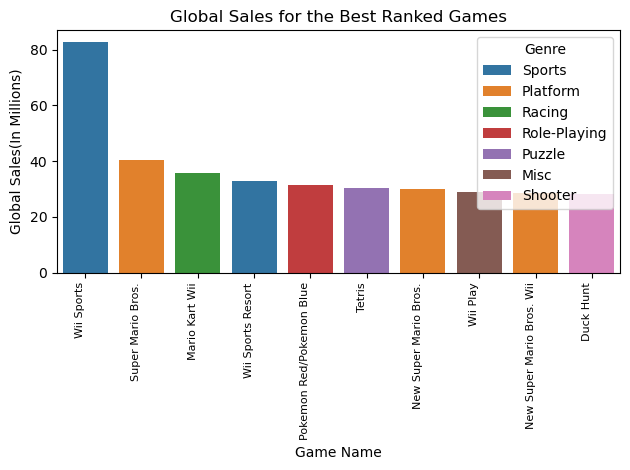

In [82]:
sns.barplot(data=lowest_ranked, x='Name', y='Global_Sales', hue = 'Genre')
# Label axes
plt.xlabel('Game Name')
plt.ylabel('Global Sales(In Millions)')
plt.title('Global Sales for the Best Ranked Games')
plt.xticks(rotation=90, ha='right', fontsize=8) 
plt.tight_layout()

Plot the second question

C:\Users\luis1\AppData\Local\Temp\ipykernel_27016\1068908240.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= dec_gen, x= 'Decade', y= 'Global_Sales', palette='pastel')


Text(0.5, 1.0, 'Which Decade dominated sales')

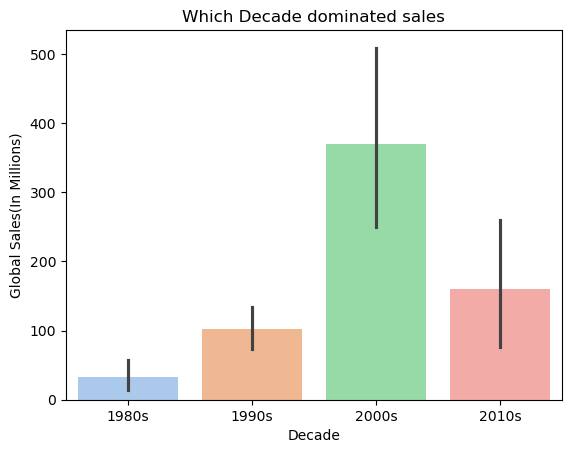

In [83]:
sns.barplot(data= dec_gen, x= 'Decade', y= 'Global_Sales', palette='pastel')
plt.xlabel('Decade')
plt.ylabel('Global Sales(In Millions)')
plt.title('Which Decade dominated sales')

Label axes 

Plot the third question

In [84]:
# Melt the dataframe to transform from wide-format into long-format
df_melted = df.melt(id_vars=['Genre'], value_vars=['NA_Sales', 'EU_Sales', 'JP_Sales'], 
                    var_name='Region', value_name='Sales')

In [85]:
# Structure the data properly so that I can create a heatmap
sales_pivot = df_melted.pivot_table(values='Sales', index='Genre', columns='Region', aggfunc='sum')

Text(0.5, 1.0, 'Breakdown of how each Genre is selling in each Region(Numbers in Millions)')

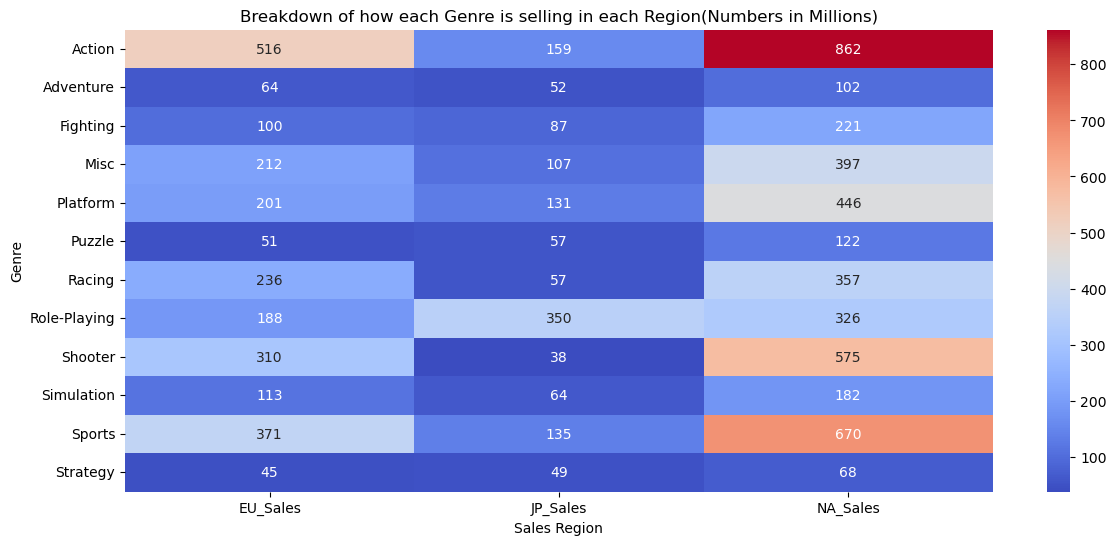

In [86]:
#Create the heatmap
plt.figure(figsize=(14,6))
sns.heatmap(sales_pivot, fmt='.0f', annot=True, cmap='coolwarm')
plt.xlabel('Sales Region')
plt.ylabel('Genre')
plt.title("Breakdown of how each Genre is selling in each Region(Numbers in Millions)")

In [88]:
# PREDICT THE GENRE OF A VIDEO GAME(ML ASPECT OF PROJECT)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

Copying df so that we could have a seperate one for our model

In [89]:
predict = df.copy()

Remove columns that you are not interested in

In [90]:
predict = predict.drop(columns=['Name', 'Rank','EU_Sales','JP_Sales','Other_Sales'])

Select the features and label

In [91]:
features = predict.loc[:, predict.columns !='Genre']
labels = df['Genre']

In [92]:
# One hot encode the categorical columns
features = pd.get_dummies(features)
features.columns

Index(['Year', 'NA_Sales', 'Global_Sales', 'Platform_2600', 'Platform_3DO',
       'Platform_3DS', 'Platform_DC', 'Platform_DS', 'Platform_GB',
       'Platform_GBA',
       ...
       'Publisher_iWin', 'Publisher_id Software', 'Publisher_imageepoch Inc.',
       'Publisher_inXile Entertainment', 'Publisher_mixi, Inc',
       'Publisher_responDESIGN', 'Decade_1980s', 'Decade_1990s',
       'Decade_2000s', 'Decade_2010s'],
      dtype='object', length=614)

In [93]:
# Train Test Split Training and Testing data
features_train, features_test, labels_train, labels_test = train_test_split(features, labels, test_size=0.3)

In [94]:
# Create an untrained model
model = DecisionTreeClassifier()

In [95]:
# Train it on the **training set**
model.fit(features_train, labels_train)

DecisionTreeClassifier()

In [96]:
# Compute training accuracy
train_predictions = model.predict(features_train)
print('Train Accuracy', accuracy_score(labels_train, train_predictions))

Train Accuracy 0.9755327545382794


In [97]:
# Compute test accuracy
test_predictions = model.predict(features_test)
print('Test Accuracy:', accuracy_score(labels_test, test_predictions))

Test Accuracy: 0.2780278232405892


My models train accuracy came out to .9739

My models test accuracy came out to .2817

This shows that my model overfit, so I will now try to remove
features and see if this gives me a better model

In [98]:
# Let's create a new DataFrame for this new model
df3 = df.copy()

In [99]:
df3.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Decade
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,2000s
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,1980s
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,2000s
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,2000s
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,1990s


In [100]:
# I'm going to filter to only the top 6 most common genres
top_genres = df3['Genre'].value_counts().nlargest(6).index
df3 = df3[df3['Genre'].isin(top_genres)]

In [101]:
# I'm going to simplify the Publisher feature by grouping rare ones under "Other"
top_publishers = df3['Publisher'].value_counts().nlargest(10).index
df3['Publisher'] = df3['Publisher'].apply(lambda x: x if x in top_publishers else 'Other')

In [102]:
# I'm going to create a new feature called "Decade" from the Year column
df3['Decade'] = (df3['Year'] // 10) * 10

In [103]:
# Now I'm going to drop columns that are not useful for this model
df3 = df3.drop(columns=['Name', 'Rank'])

In [104]:
# Select the features and label
features = df3.loc[:, df3.columns != 'Genre']
labels = df3['Genre']

In [105]:
# One hot encode the categorical columns
features = pd.get_dummies(features)

In [106]:
# Train Test Split: Training and Testing data
from sklearn.model_selection import train_test_split
features_train, features_test, labels_train, labels_test = train_test_split(
    features, labels, test_size=0.3,)

In [107]:
# Create an untrained Random Forest model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [108]:
model = RandomForestClassifier(
    max_depth=10,
    class_weight='balanced'
)

In [109]:
# Train it on the training set
model.fit(features_train, labels_train)

RandomForestClassifier(class_weight='balanced', max_depth=10)

In [110]:
# Compute training accuracy
train_predictions = model.predict(features_train)
print('Train Accuracy:', accuracy_score(labels_train, train_predictions))

Train Accuracy: 0.5680953588638092


In [111]:
# Compute test accuracy
test_predictions = model.predict(features_test)
print('Test Accuracy:', accuracy_score(labels_test, test_predictions))

Test Accuracy: 0.39810706891452236


In [112]:
# Print the classification report for more detail
print(classification_report(labels_test, test_predictions))

              precision    recall  f1-score   support

      Action       0.52      0.28      0.36       977
   Adventure       0.35      0.41      0.37       373
        Misc       0.35      0.36      0.36       485
Role-Playing       0.39      0.47      0.42       468
     Shooter       0.25      0.53      0.34       376
      Sports       0.58      0.47      0.52       702

    accuracy                           0.40      3381
   macro avg       0.41      0.42      0.40      3381
weighted avg       0.44      0.40      0.40      3381



This model is generalizaing better. Train Accuracy is .5637 and Test Accuracy is .4022.

I will now plot a confusion matrix to try to get a better understanding of the model

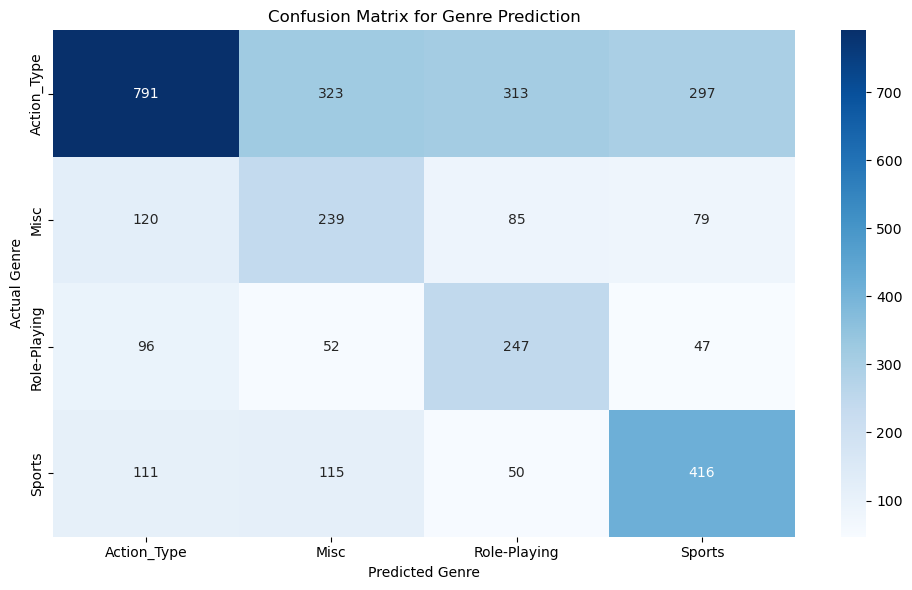

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(10,6))  # move this line before the heatmap
cm = confusion_matrix(labels_test, test_predictions, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix for Genre Prediction")
plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.tight_layout()
plt.show()


The confusion matrix is displaying that im having issues with the action, adventure and shooter categories
I think that I will try to combine similar genres and test the model again. I think that by doing this
my model will most likely be better and the generalization will improve. 

I will now create a new model with the Adventure, Action, and shooter genres turning them into 'Action_Type

In [114]:
last_model = df3.copy()

Lets add the new column in which we grouped the genres previously mentioned

In [115]:
last_model['Genre'] = last_model['Genre'].replace({'Adventure':'Action_Type', 'Action':'Action_Type', 'Shooter':'Action_Type'})
last_model['Genre']

0              Sports
3              Sports
4        Role-Playing
7                Misc
9         Action_Type
             ...     
16587          Sports
16589     Action_Type
16590    Role-Playing
16591     Action_Type
16594     Action_Type
Name: Genre, Length: 11267, dtype: object

In [116]:
#Select features and labels
features = last_model.loc[:, last_model.columns != 'Genre']
labels = last_model['Genre']

In [117]:
# One hot encode the categorical columns
features = pd.get_dummies(features)

In [118]:
# Train Test Split: Training and Testing Data
from sklearn.model_selection import train_test_split
features_train, features_test, labels_train, labels_test = train_test_split(features, labels, test_size=0.3)

In [119]:
# Create an untrained Random Forest model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [120]:
model = RandomForestClassifier(max_depth=10, class_weight= 'balanced')

In [121]:
# Train it on the training set
model.fit(features_train, labels_train)

RandomForestClassifier(class_weight='balanced', max_depth=10)

In [122]:
# Compute training accuracy
train_predictions = model.predict(features_train)
print('Train Accuracy:', accuracy_score(labels_train, train_predictions))

Train Accuracy: 0.6138726857722546


In [123]:
# Compute test Accuracy
test_predictions= model.predict(features_test)
print('Test Accuracy:', accuracy_score(labels_test, test_predictions))

Test Accuracy: 0.5007394262052647


After running my model, my train accuracy is 0.613. And my Test accuracy is 0.50. I feel like the model is now generalizing well. I will now create a confusion matrix and analyze the results of my model.

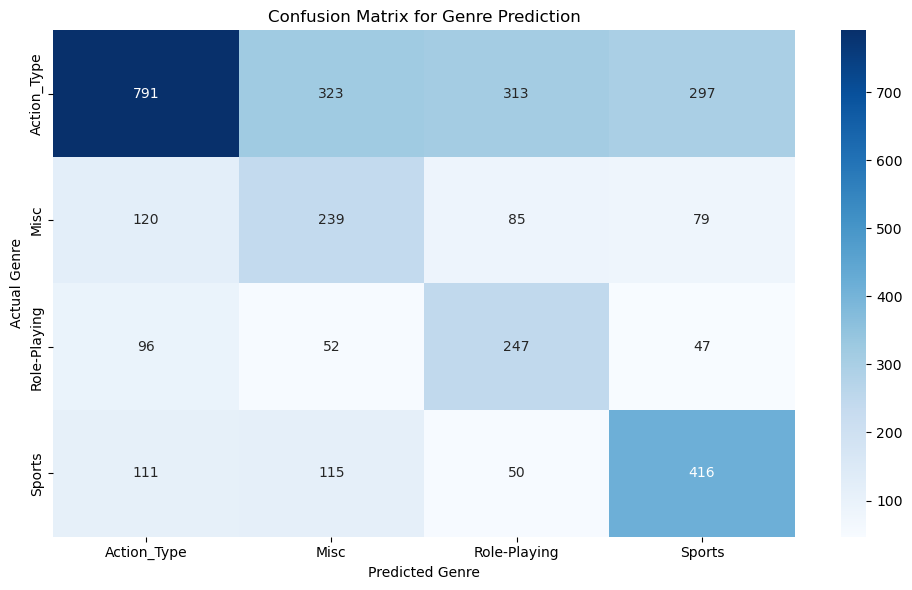

In [126]:
plt.figure(figsize=(10,6))  # create figure BEFORE plotting

cm2 = confusion_matrix(labels_test, test_predictions, labels=model.classes_)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)

plt.title("Confusion Matrix for Genre Prediction")
plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.tight_layout()
plt.show()


This models results are way better than the previous ones just based off limiting the amount of genres but 
also grouping the action type genres together.